In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import normaltest
from sklearn.preprocessing import Normalizer
import matplotlib.pyplot as plt

In [2]:
file_train = "/home/eder/projects/temporal-series/data/FordB_TRAIN.txt"
file_test = "/home/eder/projects/temporal-series/data/FordB_TEST.txt"

In [3]:
train = pd.read_csv(file_train, delimiter="  ", header=None)
test = pd.read_csv(file_test, delimiter="  ", header=None)

/tmp/ipykernel_224734/748126790.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  train = pd.read_csv(file_train, delimiter="  ", header=None)
/tmp/ipykernel_224734/748126790.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  test = pd.read_csv(file_test, delimiter="  ", header=None)


In [4]:
train.head()

,0,1,2,3,4,5,6,7,8,9,...,491,492,493,494,495,496,497,498,499,500
0,1.0,-0.731269,-0.331709,0.180212,0.729356,1.226720,1.584864,1.719098,1.622404,1.349615,...,-0.175376,-0.226743,-0.314246,-0.465901,-0.688740,-0.953811,-1.213037,-1.418047,-1.515915,-1.507342
1,-1.0,1.625923,1.174887,0.633557,0.097815,-0.323979,-0.522682,-0.501078,-0.309937,-0.053305,...,0.645025,0.149040,-0.350204,-0.763172,-1.028119,-1.146848,-1.082185,-0.872399,-0.599113,-0.264919
2,-1.0,0.943523,0.928455,0.959547,0.991248,0.996443,0.959983,0.831277,0.580112,0.235417,...,-0.637612,-0.473332,-0.332077,-0.246990,-0.230341,-0.283385,-0.312471,-0.282186,-0.173181,-0.034611
3,-1.0,-0.990329,-1.200994,-1.383529,-1.503270,-1.538072,-1.420004,-1.121234,-0.669089,-0.146006,...,-1.918893,-1.112609,-0.271551,0.495545,1.105130,1.489297,1.608930,1.509580,1.298080,1.038514
4,-1.0,1.014455,0.688760,0.372491,0.081209,-0.188529,-0.464427,-0.759484,-1.068931,-1.362857,...,0.414720,0.661333,0.827912,0.875500,0.809332,0.685075,0.552655,0.467893,0.454164,0.499379


In [5]:
(normaltest(train).pvalue > 0.5).sum()

np.int64(192)

In [6]:
normaltest(train).pvalue.shape

(501,)

In [7]:
np.any(train.isna().sum() != 0)

np.False_

In [8]:
train.shape

(3636, 501)

In [9]:
y = train[0]
x = train.drop(columns=0)

In [10]:
(y == 1).sum()

np.int64(1776)

In [11]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [12]:
nor = Normalizer()
x_train = nor.fit_transform(x_train)
x_val = nor.transform(x_val)

In [13]:
y_val.shape

(728,)

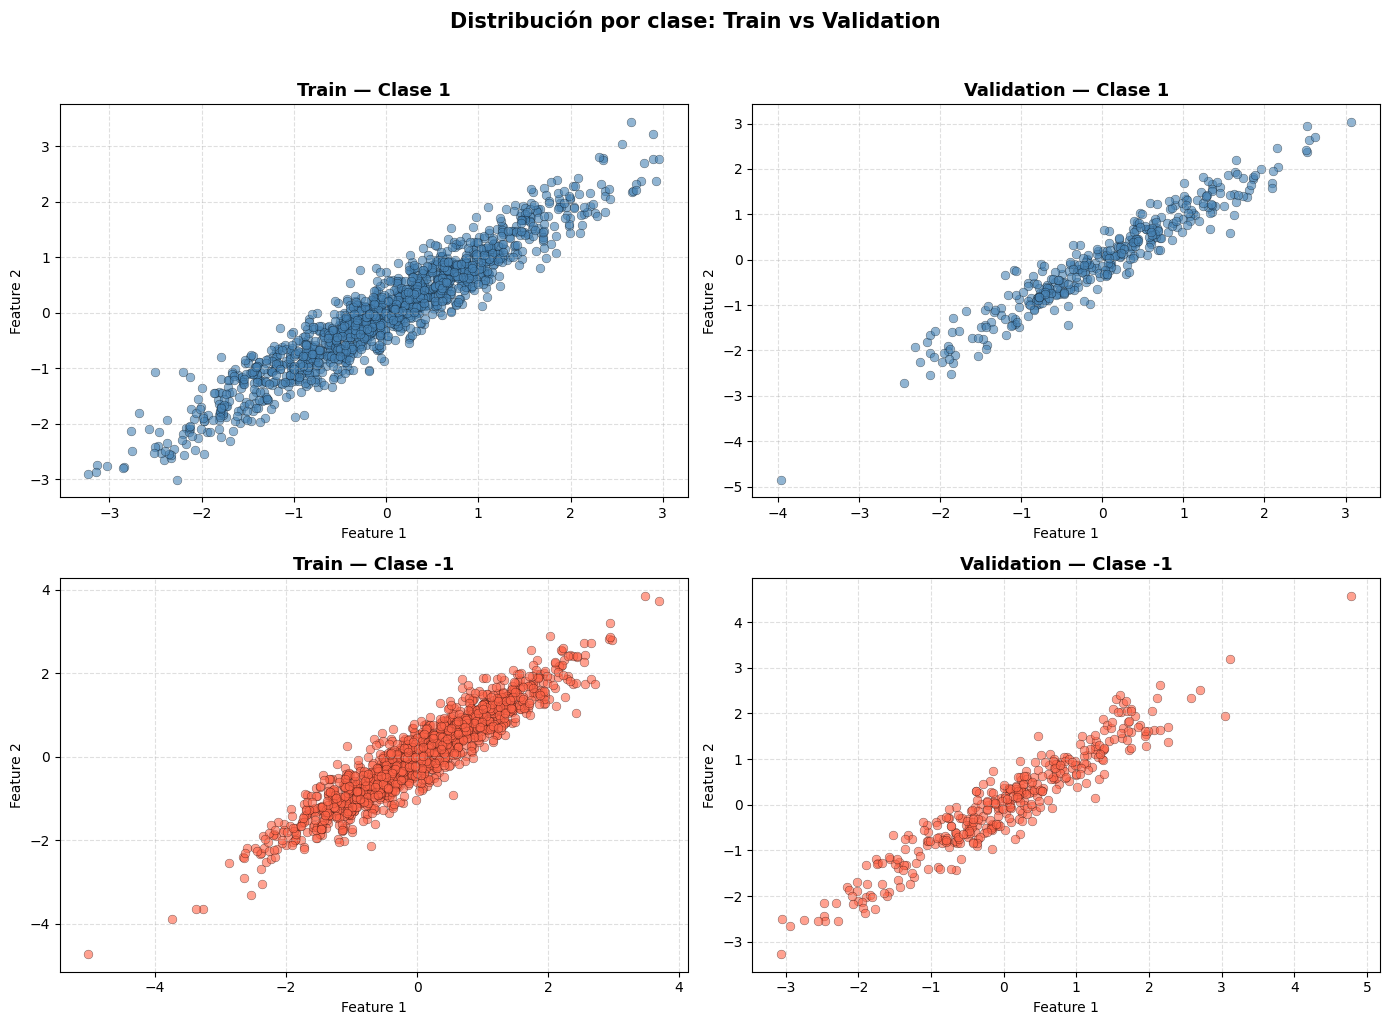

In [83]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

datasets = [
    (x_train, y_train, "Train"),
    (x_val,   y_val,   "Validation")
]

for col, (X, y, split_name) in enumerate(datasets):
    # Convertir a numpy para evitar problemas de indexación con pandas
    X_np = X.values if hasattr(X, 'values') else np.array(X)
    y_np = y.values if hasattr(y, 'values') else np.array(y)

    for row, cls in enumerate([1, -1]):
        ax = axes[row, col]
        mask = y_np == cls

        ax.scatter(X_np[mask, 0], X_np[mask, 1],
                   c='steelblue' if cls == 1 else 'tomato',
                   alpha=0.6, edgecolors='k', linewidths=0.3, s=40)

        ax.set_title(f"{split_name} — Clase {cls}", fontsize=13, fontweight='bold')
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")
        ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Distribución por clase: Train vs Validation", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [84]:
from aeon.utils.discovery import all_estimators

In [85]:
all_estimators("classifier", tag_filter={"algorithm_type": "distance"})


[('ElasticEnsemble',
  aeon.classification.distance_based._elastic_ensemble.ElasticEnsemble),
 ('KNeighborsTimeSeriesClassifier',
  aeon.classification.distance_based._time_series_neighbors.KNeighborsTimeSeriesClassifier),
 ('ProximityForest',
  aeon.classification.distance_based._proximity_forest.ProximityForest),
 ('ProximityTree',
  aeon.classification.distance_based._proximity_tree.ProximityTree)]

In [86]:
from aeon.classification.distance_based import (
    ElasticEnsemble,
    KNeighborsTimeSeriesClassifier,
    ProximityForest,
)

In [103]:
from aeon.distances import euclidean_distance, dtw_distance

In [ ]:
cls = KNeighborsTimeSeriesClassifier(distance=euclidean_distance, n_neighbors=1, n_jobs=3)

In [17]:
def results(cls, x_val, y_val):
    y_hat_train = cls.fit(x_train, y_train)
    y_hat_val = cls.predict(x_val)
    score = accuracy_score(y_val, y_hat_val)
    return score, y_hat_val, y_hat_train

In [98]:
score, val_pred, train_pred = results(cls, x_val, y_val)

In [99]:
score

0.6785714285714286

In [104]:
cls = KNeighborsTimeSeriesClassifier(distance=dtw_distance, n_neighbors=1, n_jobs=8)
score, val_pred, train_pred = results(cls, x_val, y_val)
score

0.6840659340659341

In [ ]:
X_train, y_train = load_unit_test(split="train")
X_test, y_test = load_unit_test(split="test")
clf = ElasticEnsemble(
    proportion_of_param_options=0.1,
    proportion_train_for_test=0.1,
    distance_measures = ["dtw","ddtw"],
    majority_vote=True,
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [109]:
from aeon.classification.convolution_based import MiniRocketClassifier

In [112]:
clf = MiniRocketClassifier(n_kernels=500, n_jobs=-1)
score, val_pred, train_pred = results(cls, x_val, y_val)
score


0.6840659340659341

In [135]:
from aeon.classification.convolution_based import RocketClassifier

In [136]:
clf = RocketClassifier(n_kernels=500, n_jobs=-1)
score, val_pred, train_pred = results(cls, x_val, y_val)
score

0.6840659340659341

In [14]:
from aeon.classification.deep_learning import InceptionTimeClassifier

I0000 00:00:1773938291.292432  224734 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773938292.137402  224734 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773938293.979526  224734 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [15]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  1


In [18]:
inctime = InceptionTimeClassifier(n_classifiers=5, n_epochs=50,batch_size=32, random_state=42, verbose=True)
score, val_pred, train_pred = results(inctime, x_val, y_val)
score

I0000 00:00:1773938334.342713  224734 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 500, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 500, 1)    │          0 │ input_layer[0][0] │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 500, 32)   │      1,280 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 500, 32)   │        640 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 500, 32)   │        320 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 500, 32)   │         32 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 500, 128)  │          0 │ conv1d[0][0],     │
│ (Concatenate)       │                   │            │ conv1d_1[0][0],   │
│                     │                   │            │ conv1d_2[0][0],   │
│                     │                   │            │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 500, 128)  │        512 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 500, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 500, 32)   │      4,096 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 500, 128)  │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 500, 32)   │     40,960 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 500, 32)   │     20,480 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 500, 32)   │     10,240 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 500, 32)   │      4,096 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 500, 128)  │          0 │ conv1d_5[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_6[0][0],   │
│                     │                   │            │ conv1d_7[0][0],   │
│                     │                   │            │ conv1d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 128)  │        512 │ concatenate_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 500, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 422,498 (1.61 MB)

 Trainable params: 420,450 (1.60 MB)

...

I0000 00:00:1773938825.165404  225023 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_184018__.106


90/91 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8658 - loss: 0.2814

I0000 00:00:1773938831.268833  225022 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_184018__.106


91/91 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - accuracy: 0.9085 - loss: 0.2134 - learning_rate: 0.0010
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9340 - loss: 0.1611 - learning_rate: 0.0010
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9402 - loss: 0.1498 - learning_rate: 0.0010
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9470 - loss: 0.1370 - learning_rate: 0.0010
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9525 - loss: 0.1243 - learning_rate: 0.0010
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9577 - loss: 0.1164 - learning_rate: 0.0010
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9622 - loss: 0.1046 - learning_rate: 0.0010
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9591 - loss: 0.1057 - learning_rate: 0.0010
Epoch 9/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9611 - loss: 0.1033 - learning_rate: 0.0010
Epoch 10/50
91/91 ━━━━━━━━━━━

0.9519230769230769

In [19]:
test.head()

,0,1,2,3,4,5,6,7,8,9,...,491,492,493,494,495,496,497,498,499,500
0,1.0,-0.083388,-0.155195,-0.204285,-0.200844,-0.138032,-0.015932,0.128919,0.278441,0.412761,...,0.045038,-0.170209,-0.383396,-0.553621,-0.644927,-0.641483,-0.518031,-0.302083,-0.037920,0.217653
1,-1.0,0.297655,-0.012336,-0.301982,-0.437786,-0.369755,-0.104726,0.205002,0.458375,0.532308,...,0.677769,0.395640,0.126837,-0.158503,-0.441557,-0.722243,-0.973511,-1.174684,-1.318469,-1.353255
2,1.0,0.838607,0.461138,0.016771,-0.409633,-0.755134,-0.972525,-1.059597,-1.028352,-0.921790,...,0.629446,0.764947,0.837816,0.850586,0.798947,0.678295,0.497624,0.258157,-0.010971,-0.301231
3,1.0,-3.086109,-2.882614,-2.352003,-1.557996,-0.612150,0.375694,1.268595,1.981821,2.447510,...,-0.575128,-0.384410,-0.181171,0.030169,0.227220,0.398295,0.532220,0.628262,0.677332,0.679552
4,1.0,1.525182,1.617392,1.631443,1.564634,1.439392,1.248636,0.986272,0.655790,0.274042,...,-0.978067,-0.666624,-0.367349,-0.142883,-0.001049,0.078685,0.133078,0.208365,0.338477,0.527848


In [32]:
y_test = test[0]
x_test = test.drop(columns=0)

In [ ]:
x_test = nor.transform(x_test)
y_hat = inctime.predict(x_test)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [34]:
accuracy_score(y_test.values, y_hat)

0.8506172839506173

In [39]:
inctime2 = InceptionTimeClassifier(n_classifiers=5, n_epochs=20, batch_size=64, random_state=42, verbose=True)
score, val_pred, train_pred = results(inctime2, x_val, y_val)
score

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 500, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_78    │ (None, 500, 1)    │          0 │ input_layer_13[0… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_403 (Conv1D) │ (None, 500, 32)   │      1,280 │ input_layer_13[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_404 (Conv1D) │ (None, 500, 32)   │        640 │ input_layer_13[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_405 (Conv1D) │ (None, 500, 32)   │        320 │ input_layer_13[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_406 (Conv1D) │ (None, 500, 32)   │         32 │ max_pooling1d_78… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_78      │ (None, 500, 128)  │          0 │ conv1d_403[0][0], │
│ (Concatenate)       │                   │            │ conv1d_404[0][0], │
│                     │                   │            │ conv1d_405[0][0], │
│                     │                   │            │ conv1d_406[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 128)  │        512 │ concatenate_78[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_104      │ (None, 500, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_407 (Conv1D) │ (None, 500, 32)   │      4,096 │ activation_104[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_79    │ (None, 500, 128)  │          0 │ activation_104[0… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_408 (Conv1D) │ (None, 500, 32)   │     40,960 │ conv1d_407[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_409 (Conv1D) │ (None, 500, 32)   │     20,480 │ conv1d_407[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_410 (Conv1D) │ (None, 500, 32)   │     10,240 │ conv1d_407[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_411 (Conv1D) │ (None, 500, 32)   │      4,096 │ max_pooling1d_79… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_79      │ (None, 500, 128)  │          0 │ conv1d_408[0][0], │
│ (Concatenate)       │                   │            │ conv1d_409[0][0], │
│                     │                   │            │ conv1d_410[0][0], │
│                     │                   │            │ conv1d_411[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 128)  │        512 │ concatenate_79[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_105      │ (None, 500, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 422,498 (1.61 MB)

 Trainable params: 420,450 (1.60 MB)

 Non-trainable params: 2,048 (8.00 KB)

...

I0000 00:00:1773941772.611047  225020 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_487582__.106


45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8404 - loss: 0.3044

I0000 00:00:1773941778.847244  225023 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_487582__.106


46/46 ━━━━━━━━━━━━━━━━━━━━ 17s 142ms/step - accuracy: 0.9058 - loss: 0.2177 - learning_rate: 0.0010
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9381 - loss: 0.1559 - learning_rate: 0.0010
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9453 - loss: 0.1452 - learning_rate: 0.0010
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9467 - loss: 0.1386 - learning_rate: 0.0010
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9553 - loss: 0.1211 - learning_rate: 0.0010
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9567 - loss: 0.1129 - learning_rate: 0.0010
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9635 - loss: 0.1059 - learning_rate: 0.0010
Epoch 8/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9666 - loss: 0.0981 - learning_rate: 0.0010
Epoch 9/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9646 - loss: 0.0957 - learning_rate: 0.0010
Epoch 10/20
46/46 ━━━━━━━━━━

0.9587912087912088

In [ ]:
y_hat = inctime2.predict(x_test) # 10 epochs
accuracy_score(y_test.values, y_hat)

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 205ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step


0.6864197530864198

In [ ]:
y_hat = inctime2.predict(x_test) # 20 epochs
accuracy_score(y_test.values, y_hat)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step


0.8506172839506173